# Red neuronal artificial para reconocer el tipo de un pokemon

> **Integrantes:** Eduardo Jared Montecinos, Jose Cristobal Silva, Matías Toledo

En esta tarea ustedes deben diseñar, entrenar y evaluar un modelo de red neuronal con arquitectura convolucional para resolver el problema de reconocer el tipo de un pokemon en base a una imagen del mismo y a sus atributos. El principal desafio es el desbalance y poca cantidad de ejemplos en el dataset. 

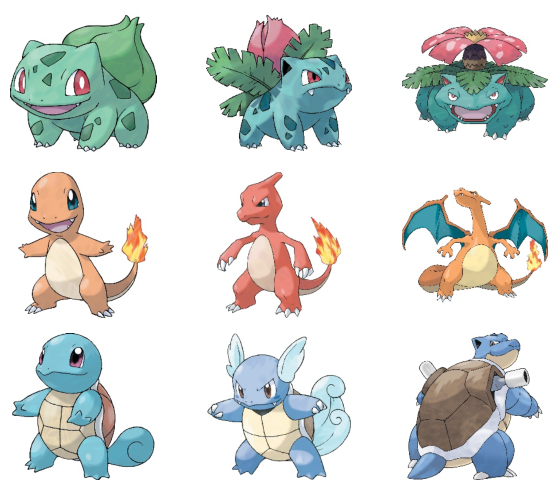

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
from pokemon_utils import PokemonImages

dataset = PokemonImages('data/')

fig, ax = plt.subplots(3, 3, figsize=(7, 5), tight_layout=True)
for ax_, (image, label, name, attributes) in zip(ax.ravel(), dataset):
    ax_.imshow(image.permute(-2, -1, 0))
    ax_.axis('off');


## Descripción del dataset

El dataset utilizado (PokemonImages) contiene 595 imágenes de Pokémon en formato RGB, de 256 X 256 píxeles, cada una asociada a su tipo principal (Type 1) como etiqueta de clasificación, además de datos adicionales: nombre, altura, peso, HP, ataque, defensa y velocidad.

In [2]:
image, label, name, attributes = dataset[0]
type(image), image.shape, label, name, attributes

(torch.Tensor,
 torch.Size([3, 256, 256]),
 np.int64(9),
 'Bulbasaur',
 tensor([ 0.7000,  6.9000, 45.0000, 49.0000, 49.0000, 45.0000]))

In [3]:
from collections import Counter
import pandas as pd
x = Counter(dataset.labels)
for key in sorted(x):
    print(f"{dataset.categories[key]}: {x[key]}")

Bug: 52
Dark: 20
Dragon: 13
Electric: 32
Fairy: 8
Fighting: 20
Fire: 34
Ghost: 18
Grass: 58
Ground: 26
Ice: 19
Normal: 80
Poison: 26
Psychic: 44
Rock: 32
Steel: 17
Water: 96


### Distribución de clases

El dataset cubre 17 tipos de Pokémon (de los 18 posibles, tipo Flying no tiene representantes como tipo primario en este dataset). La distribución está fuertemente desbalanceada:

- Las clases más representadas son Water (96), Normal (90) y Grass (58)
- Las clases menos representadas son Fairy (8), Dragon (13) y Steel (17)

Este desbalance es muy relevante ya que, debido a los pocos representantes en algunas clases, el modelo tiene dificultades para aprender patrones generalizables para los tipos menos frecuentes, lo cual se refleja más adelante en las métricas de evaluación.

In [26]:
import numpy as np
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(np.arange(len(dataset)),test_size=0.15, random_state=1234, 
                                       shuffle=True, stratify=dataset.labels)

train_dataset = Subset(dataset, train_idx)
test_dataset = Subset(dataset, test_idx)

print(f"Dataset completo: {len(dataset)}")
print(f"Total imágenes: {len(train_dataset)}")
print(f"Test: {len(test_dataset)}")

Dataset completo: 595
Total imágenes: 505
Test: 90


### División train/test

Siguiendo las indicaciones del enunciado, el dataset completo (595 imágenes) se dividió usando train_test_split con estratificación por clase (test_size=0.15, random_state=1234), obteniendo 505 imágenes para entrenamiento y 90 imágenes para test. 

La estratificación asegura que la proporción de cada tipo de Pokémon se mantenga similar en ambos conjuntos, lo cual es importante dado el desbalance ya mencionado.

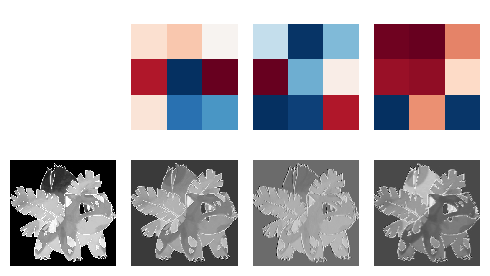

In [24]:
# Probando copiado machine learning book
import torch.nn as nn

conv_layer = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3)

example_image = train_dataset[0][0]
result = conv_layer(example_image)
example_image.shape, result.shape

fig, ax = plt.subplots(2, 4, figsize=(5, 3), tight_layout=True)
ax[1, 0].matshow(example_image[0], cmap=plt.cm.Greys)
ax[0, 0].axis('off')
ax[1, 0].axis('off')
for ax_, conv_filter in zip(ax[0, 1:], conv_layer.weight.detach().numpy()):
    ax_.matshow(conv_filter[0], cmap=plt.cm.RdBu)
    ax_.axis('off')
    
for ax_, filtered_image in zip(ax[1, 1:], result.detach().numpy()):
    ax_.matshow(filtered_image, cmap=plt.cm.Greys)
    ax_.axis('off')

### Visualización de filtros convolucionales

Para ilustrar el funcionamiento de una capa convolucional, se aplicó una capa Conv2d (3 canales de entrada, 3 de salida, kernel 3×3) sin entrenar sobre una imagen de ejemplo del dataset.

La figura muestra, en la fila superior, los tres filtros (kernels) generados aleatoriamente al inicializar la capa — cada uno una matriz 3×3 con valores positivos y negativos representados en escala de colores rojo-azul. En la fila inferior se muestra la imagen original junto con el resultado de aplicar cada uno de esos filtros a la imagen.

Al no estar entrenados, los filtros no extraen características semánticamente significativas (como bordes o texturas particulares), pero la visualización permite apreciar cómo cada filtro transforma la imagen de entrada de forma distinta según los pesos que contiene — esta es la base sobre la cual, durante el entrenamiento, la red ajusta estos pesos para aprender a detectar patrones relevantes para la tarea de clasificación.

## Definición del modelo

Para esta tarea de clasificación de imágenes (predecir el tipo principal de un Pokémon a partir de su sprite), se optó por usar transfer learning con ResNet18, una arquitectura convolucional preentrenada en ImageNet, en lugar de entrenar una CNN desde cero.

In [6]:
import torchvision.models as models
import torch

torch.manual_seed(1234) 

model = models.resnet18(weights='IMAGENET1K_V1')

# Congelar las capas base (ya saben "ver")
for param in model.parameters():
    param.requires_grad = False

# Reemplazar solo la última capa, que sí se entrena
model.fc = nn.Linear(model.fc.in_features, 18)


### Justificación de las decisiones de diseño
**1. Transfer learning en lugar de una CNN desde cero**

El dataset disponible es pequeño: solo 505 imágenes de entrenamiento repartidas en 17 clases, varias de ellas con menos de 20 ejemplos (Fairy: 8, Dragon: 13, Steel: 17). 

Entrenar una arquitectura convolucional desde cero con tan pocos datos por clase tiende a producir un modelo que memoriza en lugar de generalizar (overfitting severo), ya que no hay suficiente información para que la red aprenda por sí misma a extraer características visuales útiles (bordes, texturas, formas).

ResNet18, en cambio, ya fue entrenada sobre más de un millón de imágenes de ImageNet, por lo que sus capas convolucionales ya codifican representaciones visuales genéricas (bordes, texturas, contornos, combinaciones de color) que son reutilizables para casi cualquier tarea de clasificación de imágenes.

**2. Congelar las capas base (requires_grad = False)**

Se congelaron todos los parámetros del modelo preentrenado, dejando intactos los pesos aprendidos en ImageNet. Esta decisión busca evitar que, con tan pocos datos, el proceso de entrenamiento distorsione (y eventualmente destruya) las representaciones ya útiles que la red había aprendido — un riesgo conocido como catastrophic forgetting al hacer fine-tuning completo sobre datasets pequeños.

Al congelar el backbone, solo se entrena una pequeña cantidad de parámetros (los de la nueva capa final), lo que reduce drásticamente el riesgo de sobreajuste y hace que el entrenamiento sea mucho más rápido, ya que no es necesario calcular gradientes para la mayoría de la red.

**3. Reemplazo de la capa final (model.fc)**

La capa fc original de ResNet18 está diseñada para las 1000 clases de ImageNet. Se reemplazó por una capa lineal nueva con 18 salidas, correspondientes al número de clases necesarias para este problema (se usa 18 y no 17 porque los índices de las etiquetas del dataset van de 0 a 17, dejando un índice — el de tipo Flying — sin ejemplos, pero que debe seguir contemplado en la dimensión de salida del modelo).

Esta es la única parte de la red cuyos pesos se entrenan desde cero (inicialización aleatoria), aprendiendo a mapear las representaciones visuales genéricas extraídas por ResNet18 hacia las clases específicas de tipos de Pokémon.

## Entrenamiento del modelo

### Justificación de hiperparámetros

**- Optimizador (Adam, lr=1e-3):**

 Se eligió Adam por su capacidad de adaptar la tasa de aprendizaje por parámetro, lo cual acelera la convergencia y es menos sensible a la elección exacta del learning rate comparado con SGD simple. Un lr=1e-3 es un valor estándar para Adam y resultó apropiado dado que solo se entrena la capa fc (pocos parámetros), lo que permite converger sin inestabilidad.

**- Función de pérdida (CrossEntropyLoss, reduction='sum'):**

Es la función estándar para clasificación multiclase. Se usa reduction='sum' en lugar de 'mean' para mantener consistencia con el resto del código heredado del material del curso. El promedio por imagen se calcula manualmente al dividir por len(dataset) al final de cada época, lo que permite comparar el loss de train y validación de forma justa aunque ambos conjuntos tengan tamaños distintos.

**- Tamaño de batch (batch_size=32):**

Se eligió un valor moderado considerando el tamaño reducido del dataset (404 imágenes de entrenamiento) y las limitaciones de memoria de la GPU disponible. Un batch más pequeño (ej. 8 o 16) habría introducido más ruido en el gradiente; un batch más grande no aporta beneficio significativo dado que ya se usa una fracción considerable del dataset por batch.

**- Número de épocas (max_epochs=25):**

Se eligió este valor basándose en observación empírica de las curvas de pérdida: el loss de validación tiende a estabilizarse o comenzar a degradarse después de las primeras 15-20 épocas, por lo que 25 épocas son suficientes para observar tanto la convergencia como el inicio de un posible sobreajuste, sin incurrir en tiempos de entrenamiento innecesarios.

**- Checkpoint del mejor modelo:**

Durante el entrenamiento se guarda el estado del modelo correspondiente a la época con menor loss de validación (best_model.pt), lo que permite recuperar el modelo en su punto óptimo de generalización, evitando usar una versión sobreajustada de épocas posteriores.

In [ ]:
# soy un entrenamiento de modelo, copiado mahchine learning book
import gc
import torch
from tqdm import tqdm
import torch.utils.data as tdata

total = len(train_dataset)
valid_size = int(total * 0.2)
train_size = total - valid_size

poke_train, poke_valid = tdata.random_split(train_dataset, 
                                              [train_size, valid_size], 
                                              generator=torch.Generator().manual_seed(1234))
train_loader = tdata.DataLoader(poke_train, shuffle=True, batch_size=32)
valid_loader = tdata.DataLoader(poke_valid, shuffle=False, batch_size=32)

def train_one_step(batch):
    optimizer.zero_grad()
    data, labels = batch[0], batch[1]
    data, labels = data.to(device), labels.to(device)
    preds = model.forward(data)
    loss = criterion(preds, labels)
    loss.backward()
    optimizer.step()
    loss_value = loss.item()
    del data, labels, preds, loss  # <-- libera referencias
    return loss_value

def evaluate_one_step(batch):
    with torch.no_grad():
        data, labels = batch[0], batch[1]
        data, labels = data.to(device), labels.to(device)
        preds = model.forward(data)
        loss = criterion(preds, labels)
        loss_value = loss.item()
        del data, labels, preds, loss  # <-- libera referencias
    return loss_value

def train_one_epoch(epoch):    
    train_loss, valid_loss = 0.0, 0.0
    
    model.train()  # <-- modo entrenamiento para el loop de train
    for batch in train_loader:
        train_loss += train_one_step(batch)

    model.eval()  # <-- modo evaluación para el loop de valid (clave para BatchNorm)
    for batch in valid_loader:
        valid_loss += evaluate_one_step(batch)
        
    global best_valid_loss    
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save({'epoca': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': valid_loss}, 
                   'best_model.pt')

    torch.cuda.empty_cache()
    return train_loss/len(train_loader.dataset), valid_loss/len(valid_loader.dataset)


#optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)  # <-- solo optimiza fc
criterion = nn.CrossEntropyLoss(reduction='sum')

#device = torch.device('cpu')
device = torch.device('cuda:0')
model = model.to(device)

max_epochs, best_valid_loss = 25, np.inf
running_loss = np.zeros(shape=(max_epochs, 2))

for epoch in tqdm(range(max_epochs)):
    running_loss[epoch] = train_one_epoch(epoch)

# Al terminar el entrenamiento, libera todo lo pesado de la GPU que ya no necesitas
del optimizer

gc.collect()
torch.cuda.empty_cache()
model.eval()  # deja el modelo listo para inferencia

100%|██████████| 25/25 [00:24<00:00,  1.04it/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [8]:
batch = next(iter(train_loader))
print(type(batch))
print(len(batch))
for i, b in enumerate(batch):
    print(f"Elemento {i}: tipo={type(b)}, shape={b.shape if hasattr(b, 'shape') else 'N/A'}")

<class 'list'>
4
Elemento 0: tipo=<class 'torch.Tensor'>, shape=torch.Size([32, 3, 256, 256])
Elemento 1: tipo=<class 'torch.Tensor'>, shape=torch.Size([32])
Elemento 2: tipo=<class 'tuple'>, shape=N/A
Elemento 3: tipo=<class 'torch.Tensor'>, shape=torch.Size([32, 6])


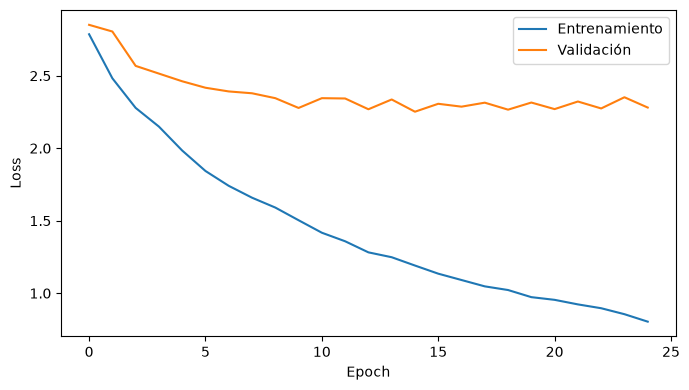

In [9]:
fig, ax = plt.subplots(figsize=(7, 4), tight_layout=True)
ax.plot(running_loss[:, 0], label='Entrenamiento')
ax.plot(running_loss[:, 1], label='Validación')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()

### Interpretación de las curvas

El gráfico muestra una clara divergencia entre el loss de entrenamiento y el de validación a medida que avanzan las épocas. El loss de entrenamiento disminuye de forma sostenida, mientras que el de validación disminuye solo durante las primeras 5-7 épocas, luego se estabiliza sin mejorar durante el resto del entrenamiento.

Esto es overfitting: después de la época 5-7, el modelo empieza a memorizar los datos de entrenamiento en vez de aprender algo que sirva para imágenes nuevas.

## Evaluación del modelo

In [ ]:
test_loader = tdata.DataLoader(test_dataset, shuffle=False, batch_size=32)
test_targets = np.array(test_dataset.dataset.labels)[test_dataset.indices]

prediction_test = []
model.eval()  # asegúrate que esté en modo eval
torch.cuda.empty_cache()

with torch.no_grad():  # <-- esto faltaba aquí
    for mbdata, label, name, attributes in test_loader:
        mbdata = mbdata.to(device)
        logits = model(mbdata)
        prediction_test.append(logits.argmax(dim=1).cpu().numpy())
        del mbdata, logits

prediction_test = np.concatenate(prediction_test)
torch.cuda.empty_cache()

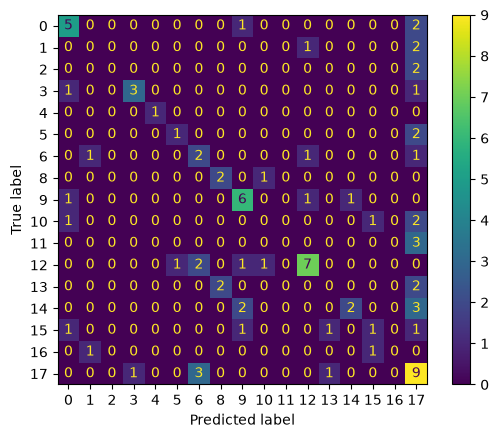

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ConfusionMatrixDisplay.from_predictions(test_targets, prediction_test);

### Matriz de confusión:

Se puede ver que el modelo tiende a confundir varias clases con la 17 (última columna, varias filas con valores altos en esa columna) y, en menor medida, con la 9. Esto sugiere que el modelo está "cayendo" hacia las clases más frecuentes del dataset cuando no está seguro, en lugar de distribuir sus errores de forma pareja entre todas las clases — un comportamiento típico cuando hay desbalance de clases.

La diagonal principal muestra aciertos claros en las clases 0, 9, 12 y 17 (las celdas más brillantes), que también son las que tienen más ejemplos tanto en entrenamiento como en test, reforzando que la cantidad de datos disponibles por clase es el factor más determinante en el desempeño del modelo.

In [12]:
print(classification_report(test_targets, prediction_test, digits=3))

              precision    recall  f1-score   support

           0      0.556     0.625     0.588         8
           1      0.000     0.000     0.000         3
           2      0.000     0.000     0.000         2
           3      0.750     0.600     0.667         5
           4      1.000     1.000     1.000         1
           5      0.500     0.333     0.400         3
           6      0.286     0.400     0.333         5
           8      0.500     0.667     0.571         3
           9      0.545     0.667     0.600         9
          10      0.000     0.000     0.000         4
          11      0.000     0.000     0.000         3
          12      0.700     0.583     0.636        12
          13      0.000     0.000     0.000         4
          14      0.667     0.286     0.400         7
          15      0.333     0.200     0.250         5
          16      0.000     0.000     0.000         2
          17      0.300     0.643     0.409        14

    accuracy              

/mnt/windows/Informatica/Inteligencia Artificial/Trabajo Unidad 3/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/windows/Informatica/Inteligencia Artificial/Trabajo Unidad 3/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/windows/Informatica/Inteligencia Artificial/Trabajo Unidad 3/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predic

El modelo alcanzó una accuracy de 0.433 sobre las 90 imágenes de test, con un f1-score weighted de 0.405 y macro de 0.344. La diferencia entre ambos confirma que el desempeño es mucho mejor en las clases grandes que en las chicas.

**- Clases con buen desempeño:** 

La clase 12 (f1=0.636, 12 ejemplos), la 0 (f1=0.588, 8 ejemplos) y la 3 (f1=0.667, 5 ejemplos) tienen resultados decentes. La clase 4, con un solo ejemplo, logra f1=1.000, aunque esto no es muy representativo dado el tamaño de muestra.

**- Clases con f1=0.000:**

Las clases 1, 2, 10, 11, 13 y 16 no fueron predichas correctamente ni una vez. Todas estas tienen muy pocos ejemplos en test (2-4 imágenes), lo que coincide con la hipótesis de que el modelo no logra aprender patrones para los tipos con menos representación en el dataset.

## Análisis de errores

La figura muestra ejemplos de Pokémon mal clasificados, agrupados por las clases reales (R) con más errores: Ground, Psychic y Water.

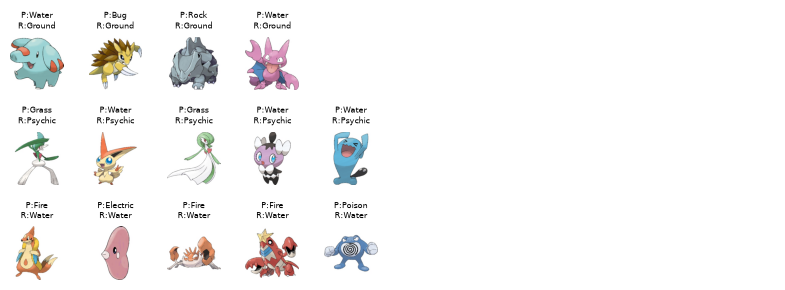

In [13]:
categories = test_dataset.dataset.categories

fig, ax = plt.subplots(3, 10, figsize=(8, 3), tight_layout=True)

for k, digit in enumerate([10, 14, 17]):
    idx = np.where((test_targets == digit) & ~(prediction_test == digit))[0]
    for i in range(10):
        ax[k, i].axis('off')
        if i < len(idx):
            real_label = test_targets[idx[i]]
            pred_label = prediction_test[idx[i]]
            real_name = categories[real_label]
            pred_name = categories[pred_label]
            ax[k, i].set_title(f"P:{pred_name}\nR:{real_name}", fontsize=6)
            ax[k, i].imshow(test_dataset[idx[i]][0].numpy().transpose(1, 2, 0))

**- Ground predicho como Water/Bug/Rock:** 

Los cuatro ejemplos (Wooper, Sandslash, Graveler, Gabite) muestran que el modelo confunde el tipo Ground con varios otros tipos distintos sin un patrón claro de color compartido — Wooper es celeste/azul (similar a Water), pero Sandslash es café/dorado y se predijo como Bug, y Graveler es gris y se predijo como Rock. Esto sugiere que el modelo no logró aprender una representación sólida para el tipo Ground, probablemente por tener pocos ejemplos de entrenamiento (26 en el dataset completo).

**- Psychic predicho como Grass/Water:** 

Este es el patrón más interesante. Los cinco ejemplos (Gardevoir, Victini, Gardevoir nuevamente, Diancie, Politoed) son predichos mayoritariamente como Water o Grass. Varios de estos Pokémon tienen tonos verdes, celestes o blancos en su diseño, lo que podría explicar por qué el modelo los asocia con esos tipos — el color parece pesar más en la decisión del modelo que otras características de forma.

**- Water predicho como Fire/Electric:** 

los últimos cinco ejemplos (Buizel/similar, un Pokémon tipo Water predicho como Electric, y otros tres predichos como Fire o Poison) muestran que el modelo confunde Water, su clase más frecuente y mejor representada, con tipos que en general no comparten un patrón de color obvio (Fire es típicamente rojo/naranjo, muy distinto al celeste/azul habitual de Water). 

Esto es algo más inesperado, incluso teniendo muchos ejemplos de entrenamiento, el modelo sigue fallando en estos casos puntuales, lo que sugiere que la variedad visual dentro de la clase Water (no todos los Pokémon de agua son azules) dificulta que el modelo aprenda una representación consistente, a pesar de la cantidad de datos disponibles.

**- Conclusión general:** 

Se observan dos patrones de error distintos. Por un lado, clases minoritarias (Ground, Psychic) tienden a confundirse con clases más frecuentes del dataset (Water, Grass), consistente con el desbalance de clases. Por otro lado, incluso la clase mayoritaria (Water) presenta errores hacia clases menos frecuentes, lo que indica que parte del problema no es solo cantidad de datos, sino también la diversidad visual dentro de cada tipo, es decir, un mismo tipo de Pokémon puede tener colores y formas muy distintas entre sí, lo que dificulta que el modelo aprenda una representación única y consistente por clase.

### Aumentación de datos

Implemente un esquema de aumentación aleatoria de datos y compare los resultados con y sin aumentación.

In [14]:
import torch
torch.manual_seed(1234) 

def entrenar_modelo(train_loader, valid_loader, device, max_epochs=25, nombre_archivo='model.pt'):
    model = models.resnet18(weights='IMAGENET1K_V1')
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 18)
    model = model.to(device)

    optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss(reduction='sum')
    
    best_valid_loss = np.inf
    running_loss = np.zeros(shape=(max_epochs, 2))

    for epoch in tqdm(range(max_epochs)):
        train_loss, valid_loss = 0.0, 0.0
        
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            data, labels = batch[0].to(device), batch[1].to(device)
            preds = model(data)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            del data, labels, preds, loss

        model.eval()
        with torch.no_grad():
            for batch in valid_loader:
                data, labels = batch[0].to(device), batch[1].to(device)
                preds = model(data)
                loss = criterion(preds, labels)
                valid_loss += loss.item()
                del data, labels, preds, loss

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save({'model_state_dict': model.state_dict()}, nombre_archivo)

        running_loss[epoch] = train_loss/len(train_loader.dataset), valid_loss/len(valid_loader.dataset)
        torch.cuda.empty_cache()
    
    return model, running_loss

In [15]:
from torch.utils.data import Dataset

class AugmentedDataset(Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base_dataset = base_dataset
        self.transform = transform
    
    def __getitem__(self, idx):
        image, label, name, attributes = self.base_dataset[idx]
        if self.transform is not None:
            image = self.transform(image)
        return image, label, name, attributes
    
    def __len__(self):
        return len(self.base_dataset)

In [16]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

# Versión con aumentación
dataset_aug = AugmentedDataset(dataset, transform=train_transform)

In [17]:
import torch
import torch.utils.data as tdata

total = len(train_dataset)
valid_size = int(total * 0.2)
train_size = total - valid_size

poke_train_base, poke_valid_base = tdata.random_split(
    train_dataset, [train_size, valid_size],  # <-- corregido
    generator=torch.Generator().manual_seed(1234)
)

poke_train = AugmentedDataset(poke_train_base, transform=train_transform)
poke_valid = poke_valid_base

train_loader = tdata.DataLoader(poke_train, shuffle=True, batch_size=32)
valid_loader = tdata.DataLoader(poke_valid, shuffle=False, batch_size=32)

In [18]:
# Sin augmentation, mismo split exacto
train_loader_noaug = tdata.DataLoader(poke_train_base, shuffle=True, batch_size=32)

In [19]:
import torchvision.models as models
from tqdm import tqdm

device = torch.device('cuda:0')

print("Entrenando SIN augmentation...")
model_noaug, loss_noaug = entrenar_modelo(train_loader_noaug, valid_loader, device, nombre_archivo='model_noaug.pt')


print("Entrenando CON augmentation...")
model_aug, loss_aug = entrenar_modelo(train_loader, valid_loader, device, nombre_archivo='model_aug.pt')

Entrenando SIN augmentation...


100%|██████████| 25/25 [00:22<00:00,  1.13it/s]


Entrenando CON augmentation...


100%|██████████| 25/25 [00:48<00:00,  1.93s/it]


In [20]:
def evaluar(model, test_loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for mbdata, label, name, attributes in test_loader:
            mbdata = mbdata.to(device)
            logits = model(mbdata)
            predictions.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(predictions)

test_loader = tdata.DataLoader(test_dataset, shuffle=False, batch_size=32)
test_targets = np.array(test_dataset.dataset.labels)[test_dataset.indices]

pred_noaug = evaluar(model_noaug, test_loader)
pred_aug = evaluar(model_aug, test_loader)

In [21]:
from sklearn.metrics import classification_report

print("=== SIN augmentation ===")
print(classification_report(test_targets, pred_noaug, zero_division=0))

=== SIN augmentation ===
              precision    recall  f1-score   support

           0       0.56      0.62      0.59         8
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         2
           3       0.75      0.60      0.67         5
           4       1.00      1.00      1.00         1
           5       0.50      0.33      0.40         3
           6       0.29      0.40      0.33         5
           8       0.50      0.67      0.57         3
           9       0.55      0.67      0.60         9
          10       0.00      0.00      0.00         4
          11       0.00      0.00      0.00         3
          12       0.70      0.58      0.64        12
          13       0.00      0.00      0.00         4
          14       0.67      0.29      0.40         7
          15       0.33      0.20      0.25         5
          16       0.00      0.00      0.00         2
          17       0.30      0.64      0.41        14

 

In [22]:
print("=== CON augmentation ===")
print(classification_report(test_targets, pred_aug, zero_division=0))

=== CON augmentation ===
              precision    recall  f1-score   support

           0       0.56      0.62      0.59         8
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         2
           3       0.80      0.80      0.80         5
           4       1.00      1.00      1.00         1
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         5
           8       0.50      0.33      0.40         3
           9       0.60      0.67      0.63         9
          10       0.00      0.00      0.00         4
          11       0.00      0.00      0.00         3
          12       0.32      0.83      0.47        12
          13       0.00      0.00      0.00         4
          14       0.50      0.29      0.36         7
          15       0.50      0.20      0.29         5
          16       0.00      0.00      0.00         2
          17       0.35      0.57      0.43        14

 

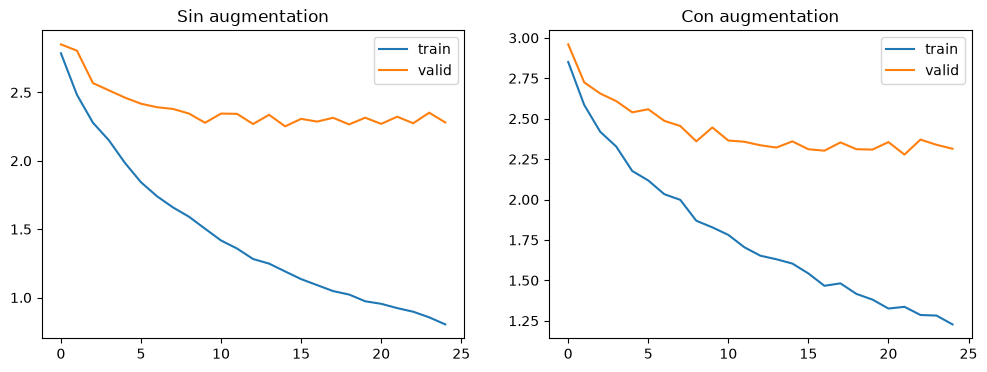

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(loss_noaug[:,0], label='train'); ax[0].plot(loss_noaug[:,1], label='valid')
ax[0].set_title('Sin augmentation'); ax[0].legend()

ax[1].plot(loss_aug[:,0], label='train'); ax[1].plot(loss_aug[:,1], label='valid')
ax[1].set_title('Con augmentation'); ax[1].legend()
plt.show()

Con un dataset tan chico, el color es una señal fuerte para el tipo de Pokémon, y el ColorJitter probablemente le está quitando esa información útil al modelo.